<a href="https://colab.research.google.com/github/andri-klymchuk/SQL-analysis--accounts-and-emails-metrics/blob/main/Python_Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1.Data overview. Understanding data and its content.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import google drive
from google.colab import drive
drive.mount("/content/drive")

# changing work folder
%cd /content/drive/MyDrive/Pandas


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Pandas


In [6]:
# uploading dataset
events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")
events.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [7]:
countries.head() # events - country : Country Code = alpha-3


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [8]:
products.head() # events - products : Product ID = id


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [9]:
events.info()
countries.info()
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-



---


So, we have 1330 records in the dataset. Some columns have missing values, we will work with them later.

We can see that all the numeric columns are recognized as numeric. The "Order Date" and "Ship Date" columns have the wrong data type, we will convert it to datetime later.

The key fields that connect the tables are "Product ID" and "id" in the "events" and "products" tables, and "Country Code" and "alpha-3" in the "events" and "country" tables.


---



##2.Data cleaning. Working with missing data, incorrect data, anomalies.

In [10]:
# Proportion of missing values to the total - %
print(events.isna().sum() / events.shape[0] * 100)


Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [11]:
print(countries.isna().sum() / countries.shape[0] * 100)


name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


---

In the events table, there are ~6% misses in Country Code, which is important because it is the key for the join. And ~0.15% of gaps in Units Sold (which is insignificant).

We have a small number of gaps in the list of countries that we can try to fix.


---

In [12]:
# extract lines with gaps
need_fix = countries[countries[["alpha-2", "region", "sub-region"]].isna().any(axis=1)]
need_fix[["name","alpha-3","alpha-2","region","sub-region"]]


,name,alpha-3,alpha-2,region,sub-region
8,Antarctica,ATA,AQ,NaN,NaN
153,Namibia,NAM,NaN,Africa,Sub-Saharan Africa


In [13]:
# filling the gaps in countries
fixes = pd.DataFrame([
    {"alpha-3": "NAM", "alpha-2": "NA", "region": "Africa", "sub-region": "Sub-Saharan Africa"},
    {"alpha-3": "ATA", "alpha-2": "AQ", "region": "Antarctic", "sub-region": None},
])

countries = countries.merge(fixes, on="alpha-3", how="left", suffixes=("","_fix"))

for col in ["alpha-2", "region", "sub-region"]:
    countries[col] = countries[col].fillna(countries[f"{col}_fix"])

countries = countries[countries.columns[~countries.columns.str.endswith("_fix")]]

countries.loc[countries["alpha-3"].isin(["NAM","ATA"])]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,Antarctic,None
153,Namibia,NA,NAM,Africa,Sub-Saharan Africa


In [14]:
print(countries.isna().sum() / countries.shape[0] * 100)


name          0.000000
alpha-2       0.000000
alpha-3       0.000000
region        0.000000
sub-region    0.401606
dtype: float64


---
We fixed Namibia and added what we could to Antarctica, which is truly an exception and has no real region or subregion.

Things are more complicated with the events table, because the data about the country is lost and there is no way to get it. But deleting the data, in my opinion, would be wrong, because **6%** is a **significant** part of the records, which can distort the final results of the analysis. Therefore, I suggest marking events with unknown geography as "Unknown" and deleting ~0.15% of gaps in Units Sold

---

In [15]:
# filling the gaps in events
events["Country Code"] = events["Country Code"].fillna("Unknown")
events = events.dropna()


In [16]:
# checking the results
print(events.isna().sum() / events.shape[0] * 100)
events.info()


Order ID          0.0
Order Date        0.0
Ship Date         0.0
Order Priority    0.0
Country Code      0.0
Product ID        0.0
Sales Channel     0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


---

Thus we lost only 2 records out of 1330

---

In [17]:
# convert the Order Date and Ship Date columns to datetime
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

print(events[["Order Date", "Ship Date"]].dtypes)


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [18]:
#checking for duplicates in data
duplicate_rows = events.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())


0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [19]:
# searching for anomalies
events[["Units Sold", "Unit Price", "Unit Cost"]].describe()


,Units Sold,Unit Price,Unit Cost
count,1328.000000,1328.000000,1328.000000
mean,4952.201807,264.913245,187.211521
std,2905.198996,217.386320,176.187801
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000



---

No duplicates, outliers, or anomalies were detected.

---


##3.Data analysis and visualization. Data analysis and visualization, finding valuable insights.


###Merging tables into one dataframe

In [20]:
# merge the data
df = pd.merge(events, products, left_on="Product ID", right_on="id", how="left")
df = pd.merge (df, countries, left_on="Country Code", right_on="alpha-3", how="left")

# get rid of duplicate keys and columns not needed for analysis:
df = df.drop(columns=["alpha-2", "alpha-3", "id", "Country Code"])

# rename columns:
df = df.rename(columns={
    "name": "Country",
    "region": "Region",
    "sub-region": "Subregion",
    "item_type": "Category",
})

# filling in new gaps
geo_cols = ["Country", "Region", "Subregion"]
df[geo_cols] = df[geo_cols].fillna("Unknown")

# fixing all text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.title()

df.head()


,Order ID,Order Date,Ship Date,Order Priority,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Subregion
0,100640618,2014-10-08,2014-10-18,M,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,7940,Online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe




---



Now we have a single clean dataframe that we can analyze.

Let's start with the key metrics

---



###Calculation of key metrics

In [21]:
total_orders = df["Order ID"].nunique()
print(f"Total orders: {total_orders}")


Total orders: 1328


In [22]:
units_sold = df["Units Sold"].sum()
print(f"Total units sold: {units_sold}")


Total units sold: 6576524.0


In [23]:
df["Revenue"] = df["Units Sold"] * df["Unit Price"]
total_revenue = df["Revenue"].sum()
print(f"Total revenue: {total_revenue}")


Total revenue: 1702129408.21


In [24]:
df["Cost"] = df["Units Sold"] * df["Unit Cost"]
total_cost = df["Cost"].sum()
print(f"Total cost: {total_cost}")


Total cost: 1200694949.21


In [25]:
df["Profit"] = df["Revenue"] - df["Cost"]
total_profit = df["Profit"].sum()
print(f"Total profit: {total_profit}")


Total profit: 501434459.0


In [26]:
covered_countries = df.loc[df["Country"] != "Unknown", "Country"].nunique()
print(f"Total covered countries: {covered_countries}")
# plus "Unknown" as a separate category (~6% of data)


Total covered countries: 45


In [27]:
by_category = df.groupby("Category")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().sort_values("Revenue", ascending=False)
print(by_category)


                      Revenue          Cost       Profit  Units Sold
Category                                                            
Office Supplies  4.022140e+08  3.242368e+08  77977176.25    617641.0
Household        2.942052e+08  2.212427e+08  72962466.77    440249.0
Cosmetics        2.331548e+08  1.404315e+08  92723306.17    533291.0
Meat             2.237620e+08  1.934243e+08  30337736.00    530380.0
Baby Food        1.436476e+08  8.970659e+07  53940997.16    562706.0
Cereal           9.579140e+07  5.453637e+07  41255034.15    465685.0
Vegetables       8.974673e+07  5.297073e+07  36776002.72    582544.0
Snacks           7.478861e+07  4.776119e+07  27027422.40    490160.0
Clothes          6.462655e+07  2.119524e+07  43431314.40    591385.0
Personal Care    4.557902e+07  3.160361e+07  13975410.68    557678.0
Beverages        2.909316e+07  1.949150e+07   9601662.78    613133.0
Fruits           5.520300e+06  4.094370e+06   1425929.52    591672.0


###Sales analysis

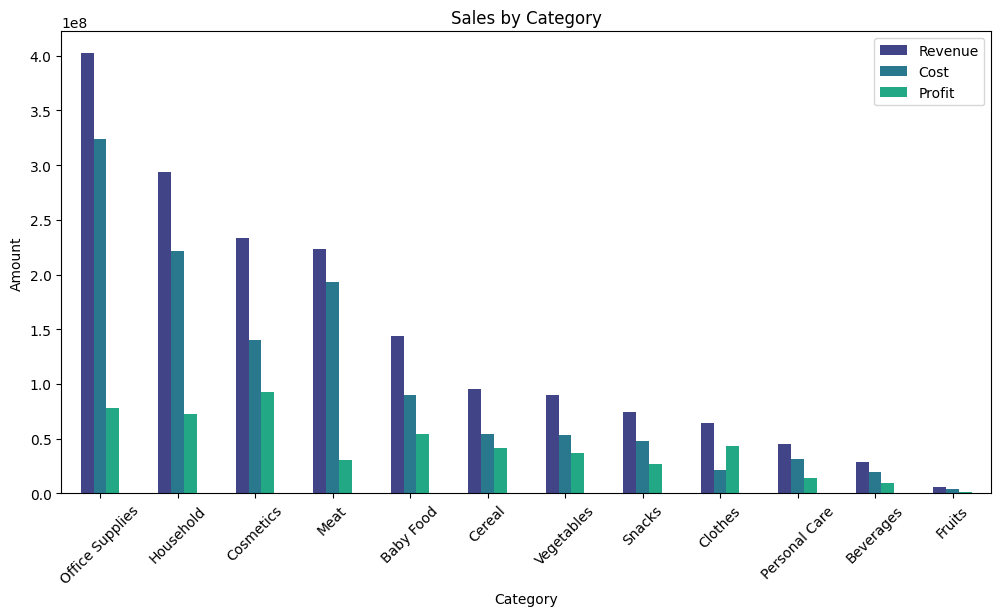

In [28]:
# analyze sales and create visualizations
colors = sns.color_palette("viridis", 4)

by_category[["Revenue", "Cost", "Profit"]].plot(
    kind="bar", figsize=(12,6),
    color=colors
)
plt.title("Sales by Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()




---


According to the analysis, it is possible to distinguish clear TOP-3 categories by profit, namely Cosmetics, Office Supplies and Household. While in terms of sales volume, there is a less clear leadership with a more uniform decline, where the top positions are occupied by Office Supplies and Beverages.


---



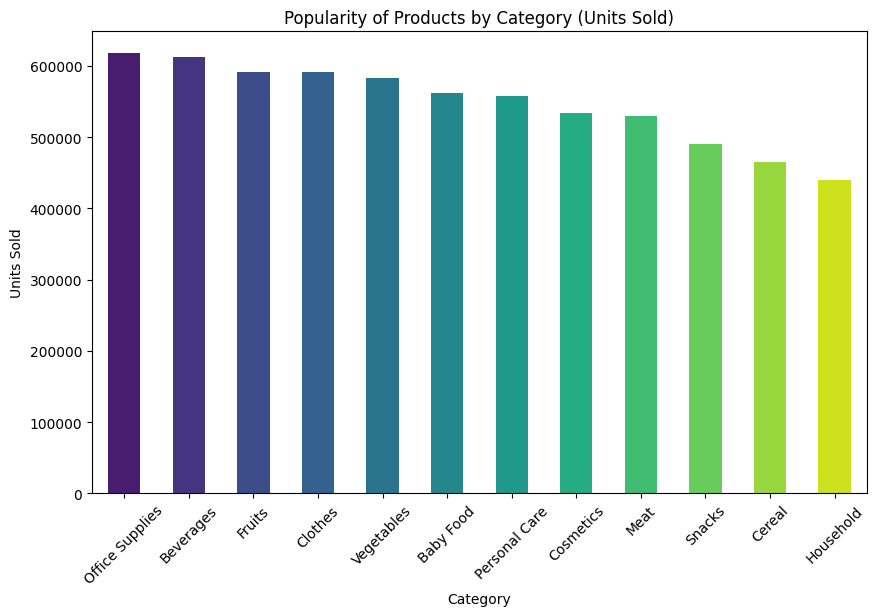

In [29]:
by_units = by_category["Units Sold"].sort_values(ascending=False)

by_units.plot(
    kind="bar", figsize=(10,6), color=sns.color_palette("viridis", len(by_units))
)
plt.title("Popularity of Products by Category (Units Sold)")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

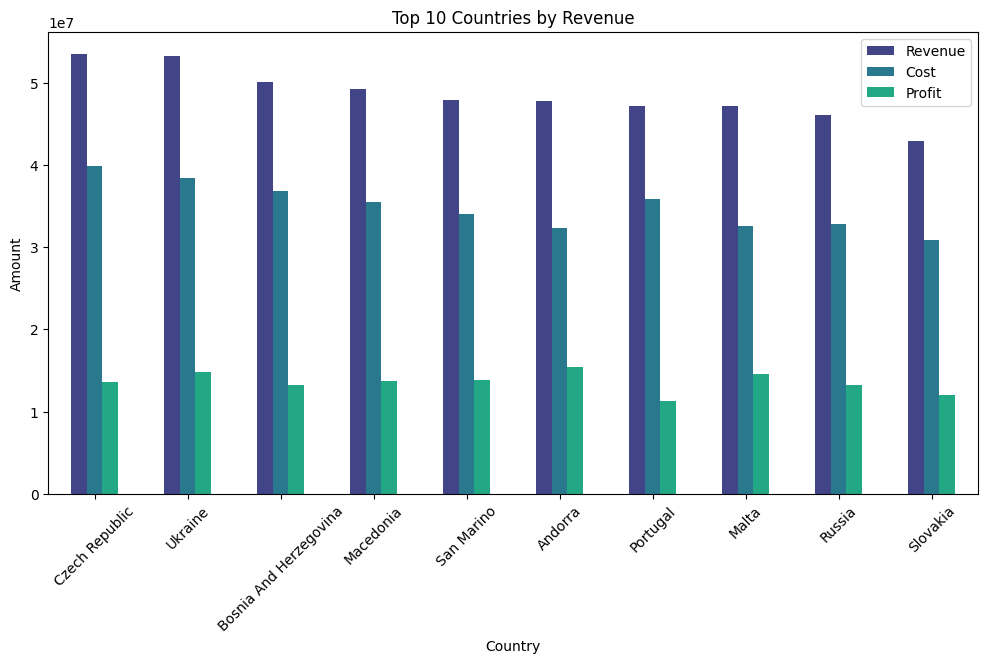

In [30]:
by_country = (
    df.loc[df["Country"] != "Unknown"]
      .groupby("Country")[["Revenue", "Cost", "Profit"]]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

by_country.plot(kind="bar", figsize=(12,6), color=colors)
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()




---


The favorites in terms of sales and profit for our company in the period from 2010 to 2017 were the countries of Southern and Eastern Europe, namely: Andorra, Ukraine, Malta, San Marino, Hungary, Macedonia, Czech Republic, russia, Bosnia and Herzegovina and others.


---



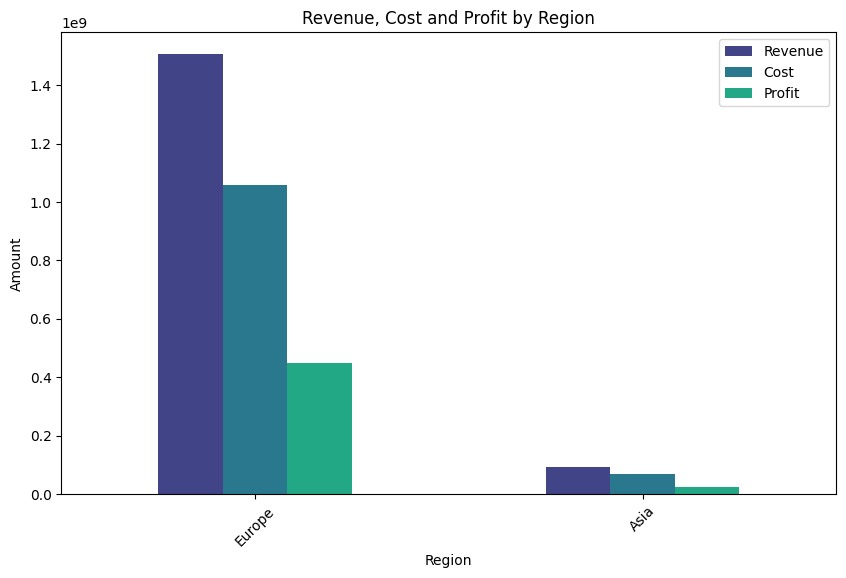

In [31]:
by_region = (
    df.loc[df["Region"] != "Unknown"]
      .groupby("Region")[["Revenue", "Cost", "Profit"]]
      .sum()
      .sort_values("Revenue", ascending=False)
)

by_region.plot(kind="bar", figsize=(10,6), color=colors)
plt.title("Revenue, Cost and Profit by Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()


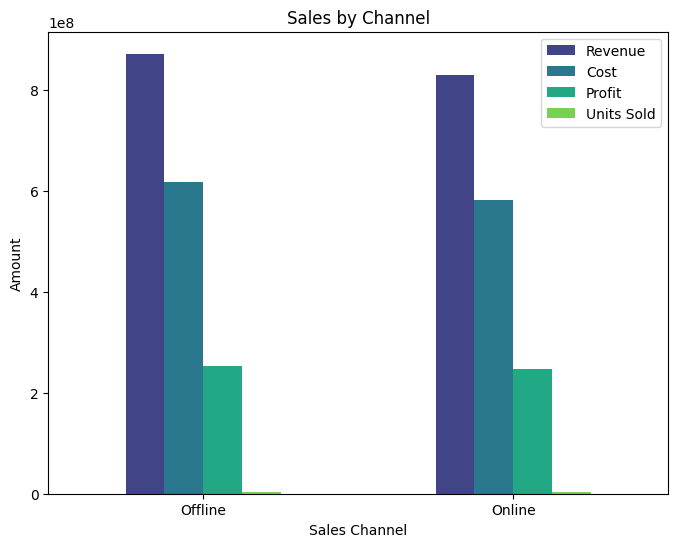

In [32]:
by_channel = df.groupby("Sales Channel")[["Revenue", "Cost", "Profit", "Units Sold"]].sum()
by_channel.plot(kind="bar", figsize=(8,6),  color=colors)
plt.title("Sales by Channel")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()


Little difference was found between online and offline sales of goods. Both sales methods account for an equal share of sales and profits

###Time interval between order and shipment

In [33]:
# analyzes the time interval between the order and its shipment
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

# checking the overall distribution
df["Shipping Time"].describe()


,Shipping Time
count,1328.000000
mean,24.786898
std,14.586041
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


In [34]:
# average delivery time by category
shipping_by_category = df.groupby("Category")["Shipping Time"].mean().sort_values()

# average delivery time by country (with filter: minimum 10 orders to avoid noise)
shipping_by_country = (
    df.groupby("Country")["Shipping Time"]
    .mean()
    .loc[lambda x: df["Country"].value_counts()[x.index] >= 10]
    .sort_values()
)

# average delivery time by region
shipping_by_region = df.groupby("Region")["Shipping Time"].mean().sort_values()


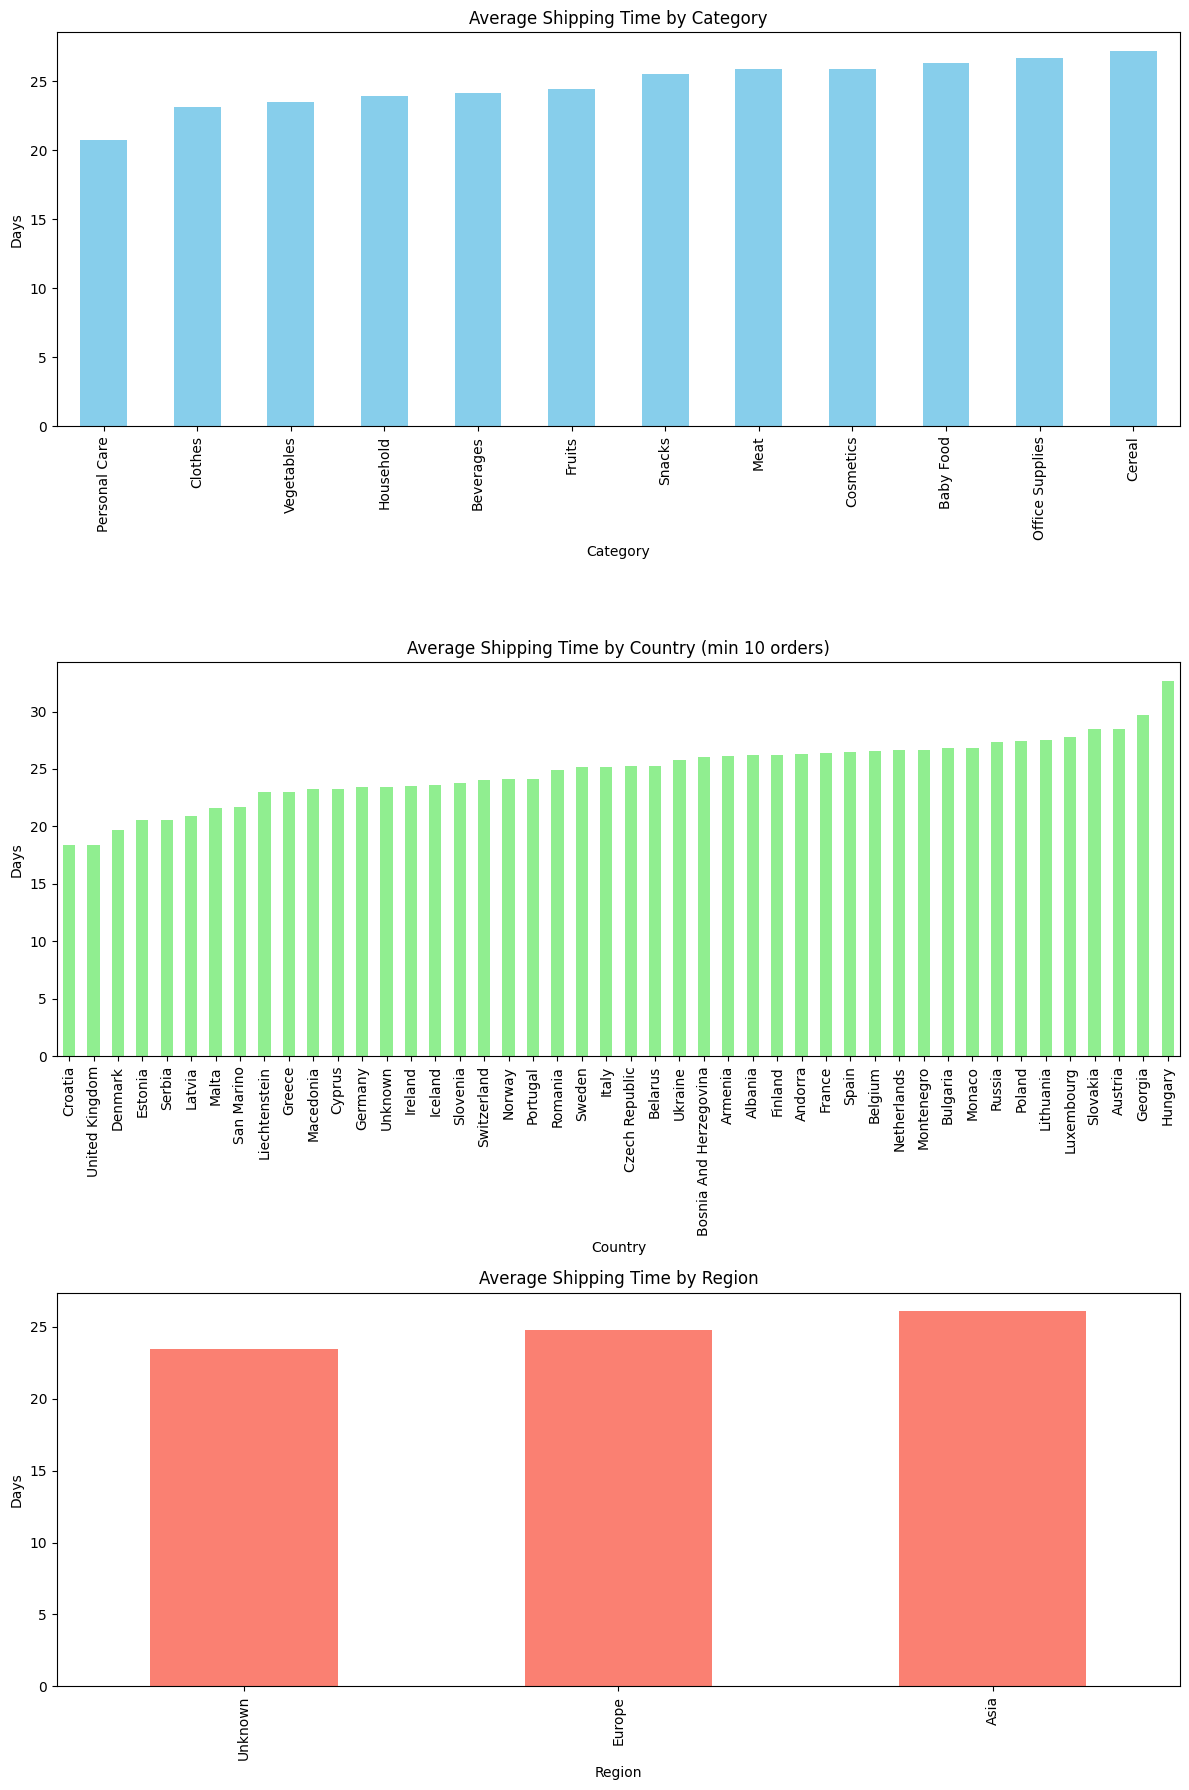

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# --- Categories ---
shipping_by_category.plot(kind="bar", ax=axes[0], color="skyblue")
axes[0].set_title("Average Shipping Time by Category")
axes[0].set_ylabel("Days")

# --- Countries ---
shipping_by_country.plot(kind="bar", ax=axes[1], color="lightgreen")
axes[1].set_title("Average Shipping Time by Country (min 10 orders)")
axes[1].set_ylabel("Days")

# --- Regions ---
shipping_by_region.plot(kind="bar", ax=axes[2], color="salmon")
axes[2].set_title("Average Shipping Time by Region")
axes[2].set_ylabel("Days")

plt.tight_layout()
plt.show()

###Does profit depend on the time it takes to ship the goods?

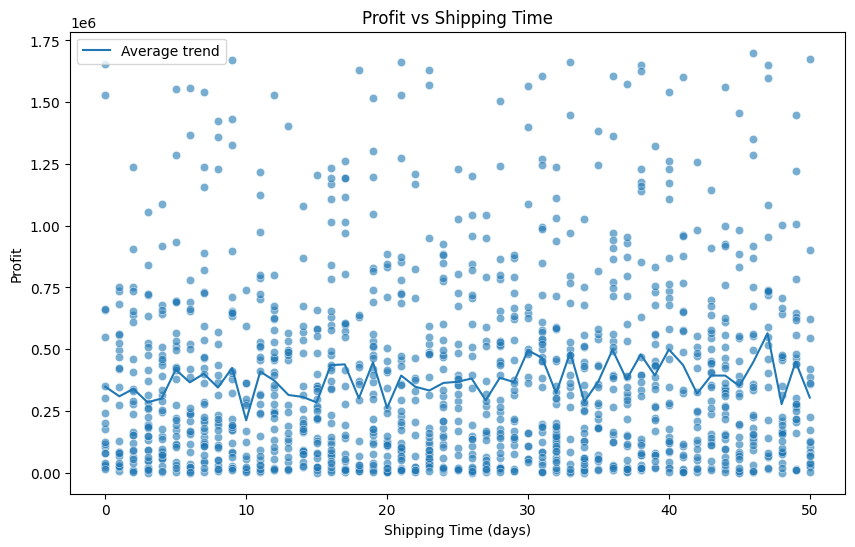

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Shipping Time", y="Profit", alpha=0.6)

profit_by_shipping = df.groupby("Shipping Time")["Profit"].mean().sort_index()
sns.lineplot(x=profit_by_shipping.index, y=profit_by_shipping.values, label="Average trend")

plt.xlabel("Shipping Time (days)")
plt.ylabel("Profit")
plt.title("Profit vs Shipping Time")
plt.legend()
plt.show()



In [37]:
corr = df["Shipping Time"].corr(df["Profit"])
print(f"Correlation between Shipping Time and Profit: {corr:.3f}")

Correlation between Shipping Time and Profit: 0.060



---

No significant correlation was found between delivery time and profit (correlation = 0.06), indicating that delivery speed does not directly affect profit margin.

---



###Sales dynamics

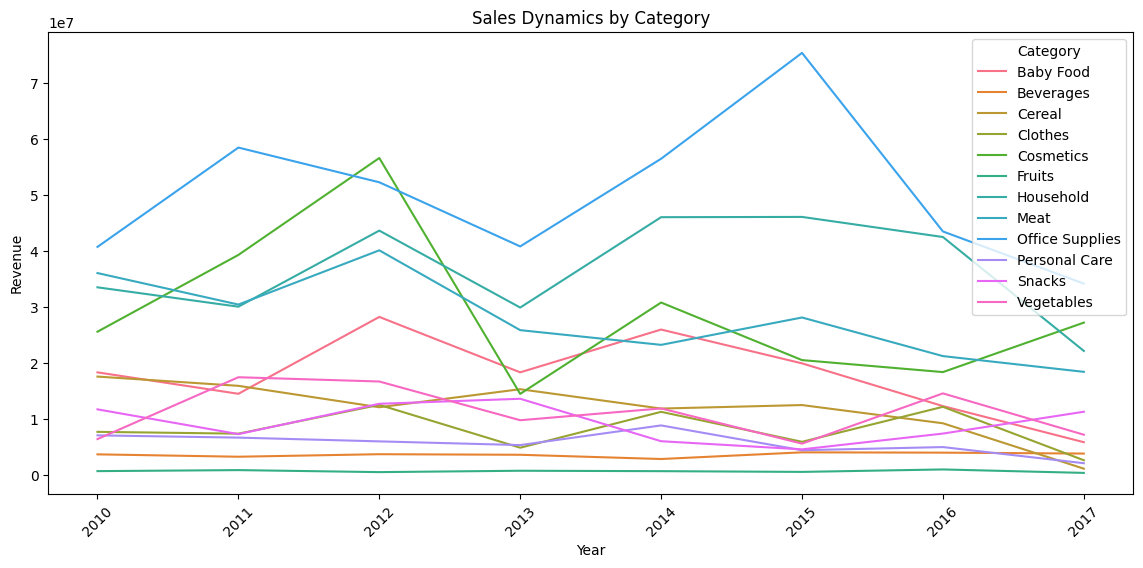

In [38]:
# add year-month for convenience
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Year"] = df["Order Date"].dt.year

dynamic_by_category = (
    df.groupby(["Year", "Category"])["Revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=dynamic_by_category, x="Year", y="Revenue", hue="Category")
plt.xticks(rotation=45)
plt.title("Sales Dynamics by Category")
plt.show()




---


Office Supplies (blue line) — consistently leads in revenue. We can say that goods maintain their positions in the dynamics.


---



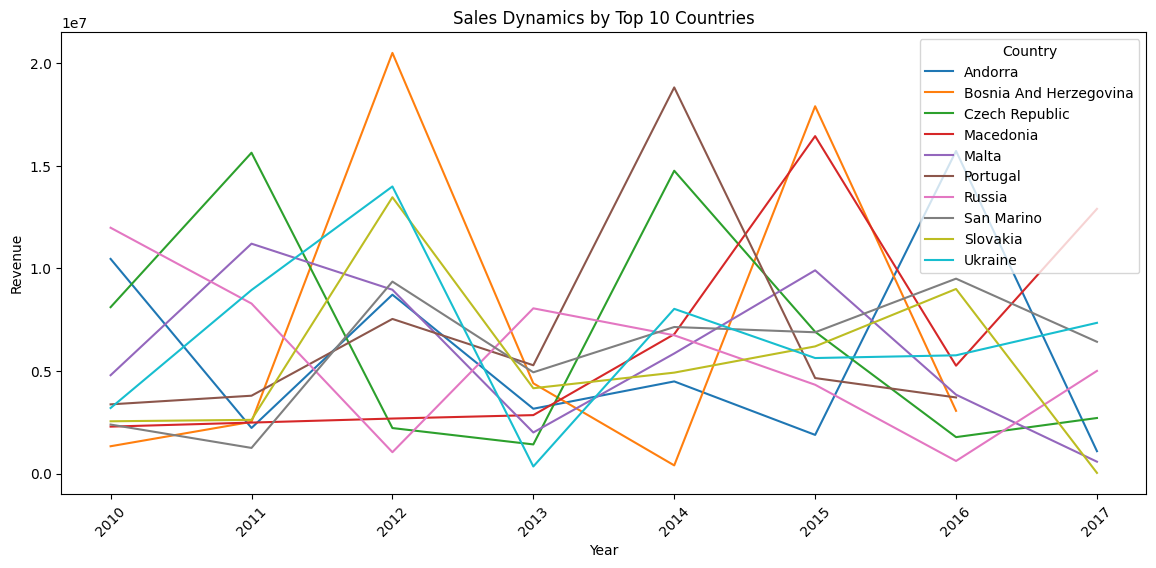

In [39]:
# dynamics by country (top 10 by revenue)
top_countries = (
    df[df["Country"] != "Unknown"]
    .groupby("Country")["Revenue"]
    .sum()
    .nlargest(10)
    .index
)

sales_by_country = (
    df[df["Country"].isin(top_countries)]
    .groupby(["Year", "Country"])["Revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=sales_by_country, x="Year", y="Revenue", hue="Country", palette="tab10")
plt.xticks(rotation=45)
plt.title("Sales Dynamics by Top 10 Countries")
plt.show()




---


The dynamics across countries have strong peaks, but also large fluctuations - the markets are unstable.


---



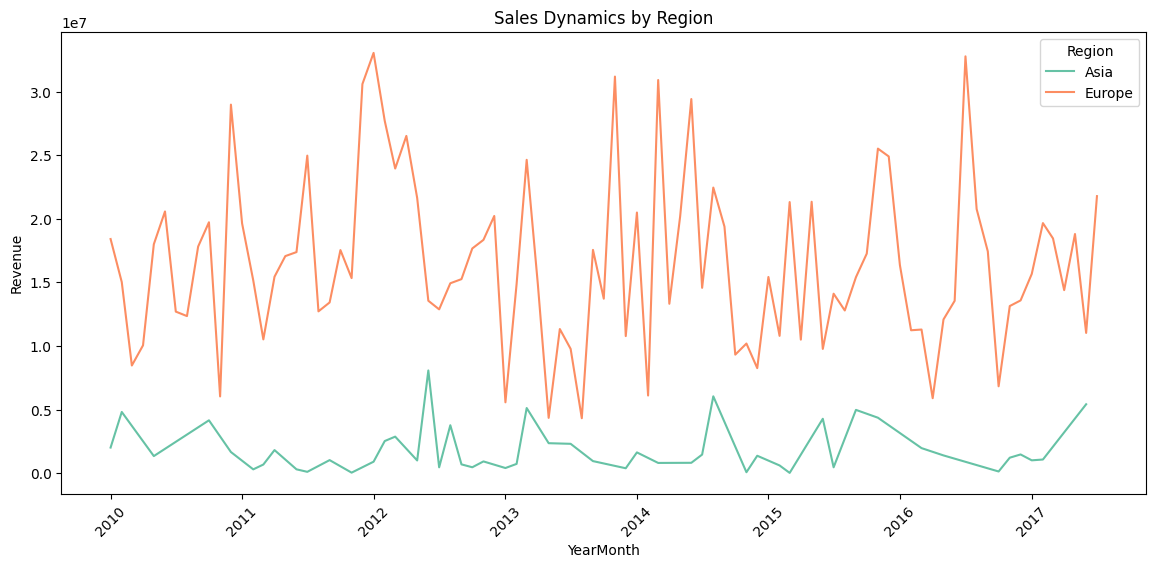

In [40]:
# dynamics by region
sales_by_region = (
    df.loc[df["Region"] != "Unknown"]
      .groupby(["YearMonth", "Region"])["Revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=sales_by_region, x="YearMonth", y="Revenue", hue="Region", palette="Set2")
plt.xticks(rotation=45)
plt.title("Sales Dynamics by Region")
plt.show()




---



Europe is the main market, bringing in the main revenue and profit, but has strong fluctuations in dynamics. Asia is currently playing the role of a supporting region with smaller volumes and a more stable picture.


---



###Sales analysis by day of the week

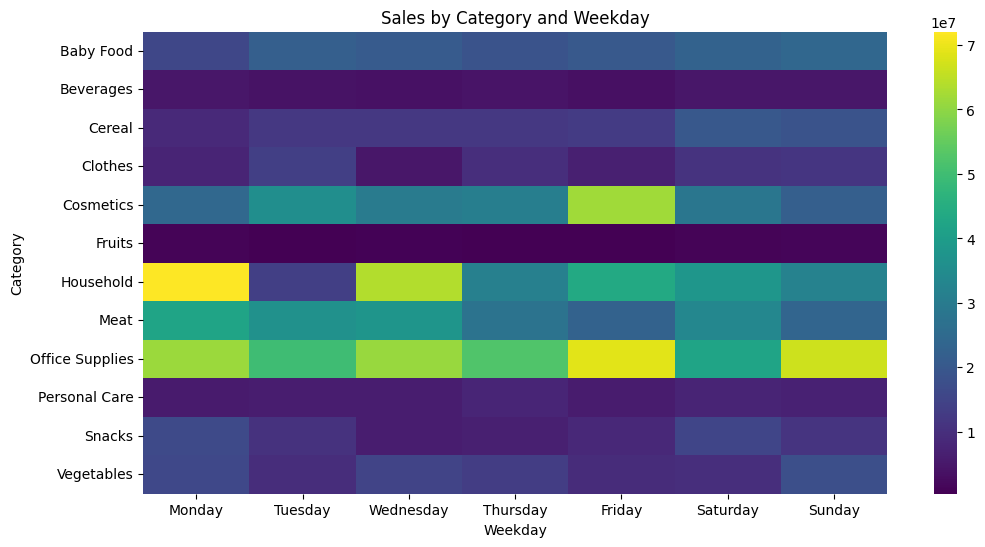

In [41]:
df["Weekday"] = df["Order Date"].dt.day_name()

# aggregation of sales by products and days
sales_by_weekday = (
    df.groupby(["Weekday", "Category"])["Revenue"]
    .sum()
    .reset_index()
)

# to keep the days of the week in the correct order
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_weekday["Weekday"] = pd.Categorical(sales_by_weekday["Weekday"], categories=order, ordered=True)

plt.figure(figsize=(12,6))
pivot = sales_by_weekday.pivot(index="Category", columns="Weekday", values="Revenue")
sns.heatmap(pivot, cmap="viridis", annot=False, cbar=True)
plt.title("Sales by Category and Weekday")
plt.show()


---


Sales patterns across weekdays show that some categories behave like weekly-seasonal goods. Office Supplies tend to sell better every other day, with peaks on Friday and Sunday. Household products peak peak on Monday and Wednesday. Cosmetics stand out with a sharp Friday spike. Other goods remain relatively stable without strong cycles on weekdays.



---



/tmp/ipykernel_5313/1859306274.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_day.index, y=profit_by_day.values, ax=axes[0], palette=palette)
/tmp/ipykernel_5313/1859306274.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_day.index, y=orders_by_day.values, ax=axes[1], palette=palette)


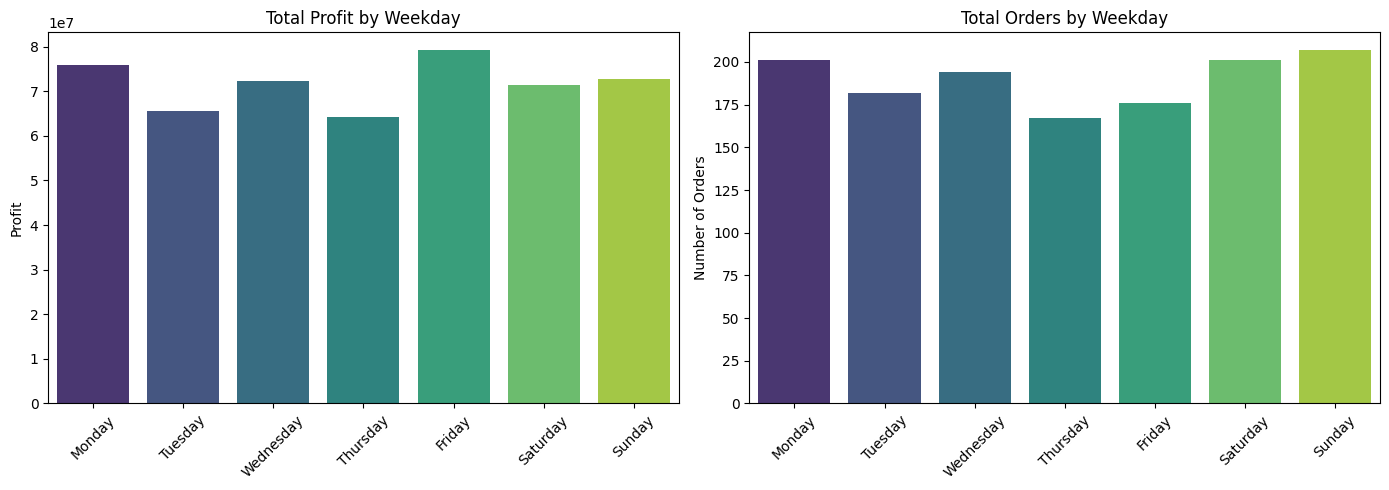

In [42]:
profit_by_day = df.groupby("Weekday")["Profit"].sum().reindex(order)
orders_by_day = df.groupby("Weekday")["Order ID"].nunique().reindex(order)

palette = sns.color_palette("viridis", 7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

sns.barplot(x=profit_by_day.index, y=profit_by_day.values, ax=axes[0], palette=palette)
axes[0].set_title("Total Profit by Weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Profit")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=orders_by_day.index, y=orders_by_day.values, ax=axes[1], palette=palette)
axes[1].set_title("Total Orders by Weekday")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##4.Reporting.

# **Sales Analysis Report (2010–2017)**

The analysis shows that the clear **TOP-3** categories by profit are Cosmetics, Office Supplies, and Household. In terms of sales volume, the leadership is more balanced, with Office Supplies and Beverages occupying the top positions.

Looking at countries, **the highest revenue and profit came from Southern and Eastern Europe**, with strong results in Andorra, Ukraine, Malta, San Marino, Macedonia, Czech Republic, Bosnia and Herzegovina, and others.

At the regional level, **Europe dominates both revenue and profit**, while Asia remains a smaller but steady contributor. Over time, Europe shows large fluctuations in monthly sales, while Asia is more stable, though at a lower level.

The correlation between shipping time and profit is very **weak**, meaning delivery time has little direct effect on profitability.

Analysis by weekday revealed clear behavioral patterns:

The highest number of sales occurs on Sundays, Saturdays, and Mondays, while Fridays generate the most revenue.

Certain categories display **weekly-seasonal trends**. For example, Office Supplies and Household peak on Mondays and Fridays, likely due to restocking habits; Cosmetics spike on Fridays, suggesting weekend-driven purchases; and Meat and Vegetables increase towards weekends, reflecting fresh product demand.

# **Conclusions**

**Keep strong stock levels** of Cosmetics, Office Supplies, and Household, as shortages in these categories would quickly impact profit.

Maintain **focus on Southern and Eastern European markets**, as they drive the majority of sales and profit.

Prepare for **peak sales between Friday and Monday**, adjusting workforce and logistics to match demand.

Monitor categories with clear weekly-seasonal demand and adapt stock and promotions accordingly.